<a href="https://colab.research.google.com/github/khalid-bin-Nasir-0/ML_arrena/blob/main/Mit_bih.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
# importing dataset

import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier


In [24]:
mit = pd.read_csv("/content/drive/MyDrive/ML dataset/ECGFiveDays_train.csv")

In [25]:
mit.head()

,0.16279070079326627,0.5406976938247681,0.7558139562606812,0.18604651093482968,0.16860465705394745,0.5465116500854492,0.6162790656089783,0.6976743936538696,0.6511628031730652,0.7034883499145508,...,0.0.48,0.0.49,0.0.50,0.0.51,0.0.52,0.0.53,0.0.54,0.0.55,0.0.56,0.0.57
0,0.990066,0.938742,0.344371,0.034768,0.273179,0.331126,0.326159,0.341060,0.347682,0.347682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.974239,0.932084,0.590164,0.131148,0.014052,0.168618,0.238876,0.210773,0.196721,0.208431,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.978495,0.723118,0.526882,0.298387,0.220430,0.158602,0.091398,0.091398,0.080645,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.963351,0.709424,0.060209,0.013089,0.057592,0.041885,0.047120,0.034031,0.039267,0.044503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967880,0.672377,0.053533,0.000000,0.089936,0.064240,0.053533,0.042827,0.029979,0.032120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [26]:
mit.shape

(3204, 188)

In [27]:
mit.value_counts('0.0.57')

,count
0.0.57,
1.0,641
3.0,641
2.0,641
4.0,641
0.0,640


In [28]:
mit = mit.rename(columns={'0.0.57': 'target'})
mit.head()

,0.16279070079326627,0.5406976938247681,0.7558139562606812,0.18604651093482968,0.16860465705394745,0.5465116500854492,0.6162790656089783,0.6976743936538696,0.6511628031730652,0.7034883499145508,...,0.0.48,0.0.49,0.0.50,0.0.51,0.0.52,0.0.53,0.0.54,0.0.55,0.0.56,target
0,0.990066,0.938742,0.344371,0.034768,0.273179,0.331126,0.326159,0.341060,0.347682,0.347682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.974239,0.932084,0.590164,0.131148,0.014052,0.168618,0.238876,0.210773,0.196721,0.208431,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.978495,0.723118,0.526882,0.298387,0.220430,0.158602,0.091398,0.091398,0.080645,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.963351,0.709424,0.060209,0.013089,0.057592,0.041885,0.047120,0.034031,0.039267,0.044503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967880,0.672377,0.053533,0.000000,0.089936,0.064240,0.053533,0.042827,0.029979,0.032120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [29]:
x = mit.drop(columns='target',axis = 1)
y = mit['target']

In [30]:
print(x)

      0.16279070079326627  0.5406976938247681  0.7558139562606812  \
0                0.990066            0.938742            0.344371   
1                0.974239            0.932084            0.590164   
2                0.978495            0.723118            0.526882   
3                0.963351            0.709424            0.060209   
4                0.967880            0.672377            0.053533   
...                   ...                 ...                 ...   
3199             1.000000            0.618321            0.683206   
3200             1.000000            0.602190            0.645985   
3201             0.400673            0.341190            0.281706   
3202             0.696510            0.594841            0.471927   
3203             1.000000            0.938644            0.881593   

      0.18604651093482968  0.16860465705394745  0.5465116500854492  \
0                0.034768             0.273179            0.331126   
1                0.131148      

In [31]:
x.head()

,0.16279070079326627,0.5406976938247681,0.7558139562606812,0.18604651093482968,0.16860465705394745,0.5465116500854492,0.6162790656089783,0.6976743936538696,0.6511628031730652,0.7034883499145508,...,0.0.47,0.0.48,0.0.49,0.0.50,0.0.51,0.0.52,0.0.53,0.0.54,0.0.55,0.0.56
0,0.990066,0.938742,0.344371,0.034768,0.273179,0.331126,0.326159,0.341060,0.347682,0.347682,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.974239,0.932084,0.590164,0.131148,0.014052,0.168618,0.238876,0.210773,0.196721,0.208431,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.978495,0.723118,0.526882,0.298387,0.220430,0.158602,0.091398,0.091398,0.080645,0.083333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.963351,0.709424,0.060209,0.013089,0.057592,0.041885,0.047120,0.034031,0.039267,0.044503,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967880,0.672377,0.053533,0.000000,0.089936,0.064240,0.053533,0.042827,0.029979,0.032120,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [33]:
cv_score = cross_val_score(RandomForestClassifier(), x, y, cv=5)
cv_score

array([0.87363495, 0.86583463, 0.89235569, 0.87675507, 0.9078125 ])

In [35]:
model = RandomForestClassifier()
model.fit(x, y)
predictions = model.predict(x)

Accuracy Score: 1.0000

Confusion Matrix:
[[640   0   0   0   0]
 [  0 641   0   0   0]
 [  0   0 641   0   0]
 [  0   0   0 641   0]
 [  0   0   0   0 641]]


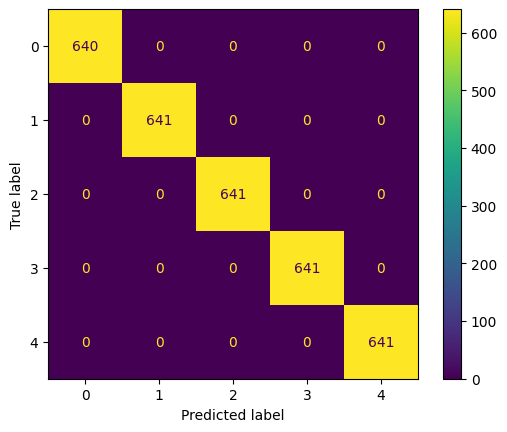

In [38]:
# Compute accuracy score
accuracy = accuracy_score(y, predictions)
print(f"Accuracy Score: {accuracy:.4f}\n")

# Compute and display confusion matrix
cm = confusion_matrix(y, predictions)
print("Confusion Matrix:")
print(cm)

# Optional: Visual display of the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [41]:
test_data = pd.read_csv('/content/drive/MyDrive/ML dataset/ECGFiveDays_test.csv')
test_data.head()
test_data.tail()

,0.9670885801315309,0.6860759258270264,0.23037974536418915,0.053164556622505195,0.0835443064570427,0.050632912665605545,0.017721518874168396,0.037974681705236435,0.03544303774833679,0.010126582346856594,...,0.0.84,0.0.85,0.0.86,0.0.87,0.0.88,0.0.89,0.0.90,0.0.91,0.0.92,0.0.93
804,0.647351,0.541391,0.425497,0.309603,0.165563,0.091060,0.034768,0.026490,0.043046,0.099338,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
805,0.759350,0.661789,0.544715,0.403252,0.258537,0.167480,0.094309,0.063415,0.071545,0.105691,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
806,1.000000,0.841237,0.783505,0.760825,0.845361,0.843299,0.692784,0.515464,0.334021,0.430928,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
807,0.632184,0.583333,0.551724,0.551724,0.531609,0.497126,0.436782,0.390805,0.278736,0.172414,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
808,1.000000,0.930337,0.858427,0.774157,0.658427,0.524719,0.400000,0.296629,0.203371,0.158427,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


In [42]:
test_y = test_data['0.0.93']
test_data = test_data.drop(columns='0.0.93',axis = 1)

In [44]:
test_pred = model.predict(test_data.values)

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [45]:
acc = accuracy_score(test_y,test_pred)

In [49]:
print(acc*100)

87.63906056860321


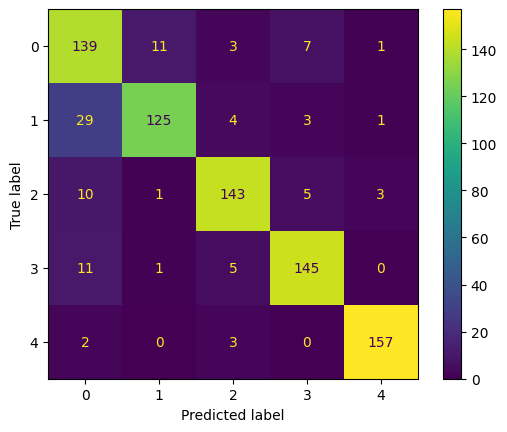

In [48]:
cm = confusion_matrix(test_y, test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()